# Project n°3 : Vision Transformers vs. Convolutional Neural Networks

**Authors** : Selim Ben Abdallah¹, Paola De Truchis¹, Eduardo De Jesus Zancanaro Garcia¹, and Edda Iveland¹ \
¹ INSA Toulouse

The goal of this project is to compare the performance of vision transformers (ViTs) to convolutional neural networks (CNNs) on the task of image classification on labelled datasets.

---
---

**Our notebook is structured as follows :**

1. **Presentation of the datasets**
- CIFAR-10
- Food-101 ?

2. **Convolution Neural Networks**
- Custom CNN, ResNet-18

3. **Vision Transformers**
- ViT-Tiny, Swin-Tiny

4. **Comparison**

5. **Conclusion**


---
---

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import utils.utils_metrics_project_3 as ump3
import utils.utils_train_eval_project_3 as utep3

importlib.reload(ump3)
importlib.reload(utep3)

from utils.utils_metrics_project_3 import get_confusion_matrix, plot_history, plot_confusion_matrix, pick_indices, show_predictions_grid, top_confusions, show_predictions_grid_viz
from utils.utils_train_eval_project_3 import train_model, evaluate

import models.models_project_3 as mp3
importlib.reload(mp3)
from models.models_project_3 import Custom_CNN, Custom_CNN_v2

/Users/selimbenabdallah/Workspace/code/hddl/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_CNN_V1_CIFAR = False
TRAIN_CNN_V2_CIFAR = True

---
---

# Brainstorming + Infos

**Models**
- Custom CNN
- ResNet-18
- ViT-Tiny/16 (patch size : 16, embed dim : 192, depth : 12, heads : 3) (smaller than ViT B-16)
- Swin-T (Swin Tiny)

**Datasets**
- CIFAR-10 : 60k images, 32x32, 10 classes (50k train / 10k test)
- Food-101 : 101k images, 101 classes (750 train + 250 test per class, noisy training set)
- Important : For ImageNet-pretrained fine-tuning: resize/crop inputs to 224×224 for ResNet/ViT/Swin (and ideally also for the custom CNN for fair time/memory comparison)



**Training settings**
- Train from scratch on CIFAR-10 (4 from-scratch trainings)
- Train from scratch on Food-101 (4 from-scratch trainings)

| Dataset | Type | Custom CNN | ResNet-18 | ViT-Tiny | Swin-T |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | From Scratch | 224 | 224 | 224 | 224 |
| Food-101 | From Scratch| 224 | 224 | 224 | 224 |

**Calculated metrics**
- best_val_acc : highest validation accuracy reached during training
- final_val_acc : validation accuracy after training fineshed, evaluated using the best weights
- final_test_acc : accuracy on the test set, using the best validation model
- final_val_macro_f1 : macro_f1 is the average of per-class f1_scores (each class contributes equally), final_val_marcro_f1 is the macro_f1 on the val set using the best model
- final_test_macro_f1 : macro_f1 on the test set using the best model
- total_training_time_sec : total training time in sec
- traink_peak_mem_bytes : The maximum torch.mps.current_allocated_memory() observed during training batches
- val_peak_mem_bytes : peak allocated memory observed during validation
- test_peak_mem_bytes : same for the test loop



---
---

## 1 - Datasets

### 1.1 - Dataset construction

#### 1.1.1 - CIFAR-10

The CIFAR-10 dataset contains 60000 labelled images of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. The images are coloured and of size 32x32, so the **images are not too big**. This makes training processes quicker. As the dataset is neither too big nor too small, we hope that differences in performance between CNNs and ViTs will not be due to the dataset scale, but rather the models themselves. 

We will we defining the ViT and CNN **from scratch**, so using a dataset that is easier to train from scratch is essential. If we were to use a dataset with larger images, pretrained weights would have yielded higher performance, making it harder to compare models from scratch. 

Each class in the CIFAR-10 dataset contains the **same number of images** and labels are clear and distinguished. Consequently, differences between CNNs and ViTs will not be due to class imbalances or noisy annotations. 

Additionally, CIFAR-10 has been **extensively studied**, aiding the comparison we will perform at the end of this project to the literature. 

-   Note : first download takes 2 minutes

In [3]:
IMG_SIZE = 224

# CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
# CIFAR_STD  = (0.2470, 0.2435, 0.2616)

IMAGENET_MEAN = (0.485, 0.456, 0.406) # We are going to use same normalization for both datasets
IMAGENET_STD  = (0.229, 0.224, 0.225)

IMAGENET_MEAN_TENSOR = torch.tensor([0.485, 0.456, 0.406]) #used when plotting predictions
IMAGENET_STD_TENSOR  = torch.tensor([0.229, 0.224, 0.225])


# CIFAR-10 (resized to 224*224)
train_transform_cifar = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform_cifar = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


train_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False, # Set to False if already downloaded                      
    transform=train_transform_cifar
)

test_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=False,   # Set to False if already downloaded                     
    transform=test_transform_cifar
)

# We will train on 224x224 images, but we will visualize 32x32 images
viz_cifar_test = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=False,
    transform=transforms.ToTensor()   # no resize, no normalize
)

#### 1.1.2 - Food-101

- Presentation Food-101

-   Note : first download takes 30 minutes

In [4]:
# Food-101
train_transform_food = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

test_transform_food = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Bug : downloading freezed at 89%, re-try later (set to False in the meantime)
# train_food = datasets.Food101(
#     root="./datasets/dataset_project_3/food101", #once downloaded keep this root and keep and switch to 'False'
#     split="train",
#     download=False,                      
#     transform=train_transform_food
# )

# test_food = datasets.Food101(
#     root="./datasets/dataset_project_3/food101",
#     split="test",
#     download=False,                      
#     transform=test_transform_food
# )

#### 1.1.3 - Sanity checks

In [5]:
# CIFAR-10 checks
print("CIFAR-10 SANITY CHECKS ")
print("Train size:", len(train_cifar))
print("Test size :", len(test_cifar))

print("The classes of the CIFAR-10 dataset are:")
cifar_class_names = train_cifar.classes
print(cifar_class_names)
print("---------------------")
print("There are", len(cifar_class_names), "classes")

x, y = train_cifar[0]
print("One sample:")
print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
print("Label index:", y, "| class name:", cifar_class_names[y])


CIFAR-10 SANITY CHECKS 
Train size: 50000
Test size : 10000
The classes of the CIFAR-10 dataset are:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
---------------------
There are 10 classes
One sample:
Image shape: torch.Size([3, 224, 224])
Label index: 6 | class name: frog


In [6]:
# Food-101 checks
# print("FOOD-101 SANITY CHECKS")
# print("Train size:", len(train_food))
# print("Test size :", len(test_food))

# print("The classes of the Food-101 dataset are:")
# food_class_names = train_food.classes
# print(food_class_names[:10], "...") # first 10 (there are 101 classes)
# print("---------------------")
# print("There are", len(food_class_names), "classes")

# x, y = train_food[0]
# print("\nOne sample:")
# print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
# print("Label index:", y, "| class name:", food_class_names[y])


#### 1.1.4 - Train / Val / Test

In [7]:
# CIFAR-10 (creation of the validation split)
SEED = 42
VAL_FRACTION = 0.2   # train_cifar is splitted this way : 80% train & 20% validation

cifar_train_eval = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False,
    transform=test_transform_cifar, #no augmentations
)

n_total = len(train_cifar)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED) # number generator (randomness for random_split)

train_cifar_split, val_tmp = random_split(train_cifar, [n_train, n_val], generator=g)
val_cifar_split = Subset(cifar_train_eval, val_tmp.indices) # here we take the same validation images selecte by random_split(), but we load them from a dataset object that uses eval transforms
test_cifar_split = test_cifar #just renaming 

print("CIFAR sizes = train:", len(train_cifar_split), "val:", len(val_cifar_split), "test:", len(test_cifar_split))


CIFAR sizes = train: 40000 val: 10000 test: 10000


In [8]:
# Food-101 (creation of the validation split)

# SEED = 42
# VAL_FRACTION = 0.2  # 20% validation

# # Eval-transform view of the Food training split (for validation)
# food_train_eval = datasets.Food101(
#     root="./datasets/dataset_project_3/food101",
#     split="train",
#     download=False,
#     transform=test_transform_food,
# )

# n_total = len(train_food)
# n_val = int(round(n_total * VAL_FRACTION))
# n_train = n_total - n_val

# g = torch.Generator().manual_seed(SEED)

# train_food_split, val_tmp = random_split(train_food, [n_train, n_val], generator=g)
# val_food_split = Subset(food_train_eval, val_tmp.indices)
# test_food_split = test_food #just renaming 

# print("Food sizes -> train:", len(train_food_split), "val:", len(val_food_split), "test:", len(test_food_split))


#### 1.1.5 - DataLoaders

In [9]:
BATCH_SIZE = 32
NUM_WORKERS = 0

cifar_loaders = {
    "train": DataLoader(train_cifar_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
    "val":   DataLoader(val_cifar_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    "test":  DataLoader(test_cifar,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

# food_loaders = {
#     "train": DataLoader(train_food_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
#     "val":   DataLoader(val_food_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
#     "test":  DataLoader(test_food,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
# }

# quick check
xb, yb = next(iter(cifar_loaders["train"]))
print("CIFAR batch:", xb.shape, yb.shape)

# xb, yb = next(iter(food_loaders["train"]))
# print("Food batch:", xb.shape, yb.shape)

CIFAR batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


## 2 - Convolutional Neural Networks

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(device)

mps


### 2.1 - Custom CNN

#### 2.1.1 - CNN - CIFAR-10 (Test CNN "V1")

In [12]:
MODEL_NAME = "cnn_v1_cifar_test_10ep"
if TRAIN_CNN_V1_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)

    model_cnn_cifar, history, metrics, saved_path = train_model(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=10,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN on CIFAR-10")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)
    model_cnn_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

mps
Loaded checkpoint keys: dict_keys(['model_state_dict', 'history', 'metrics', 'config'])
Saved metrics: {'best_val_acc': 0.47693690095846647, 'best_epoch': 10, 'final_val_acc': 0.47693690095846647, 'final_val_macro_f1': 0.4699673225331914, 'final_test_acc': 0.4790335463258786, 'final_test_macro_f1': 0.47167701391277606, 'total_training_time_sec': 881.486088790989, 'train_peak_mem_bytes': 21103872, 'val_peak_mem_bytes': 14681344, 'test_peak_mem_bytes': 14681344, 'device': 'mps', 'lr': 0.0003, 'epochs': 10}


Test loss: 1.4440444589803776
Test acc : 0.4790335463258786
Confusion matrix shape: (10, 10)


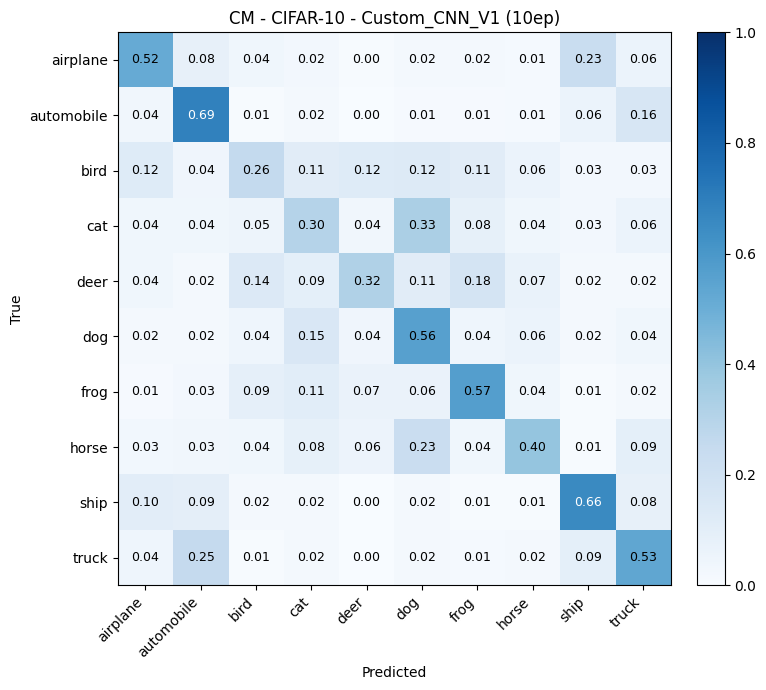

In [13]:
# Evaluate

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - Custom_CNN_V1 (10ep)")

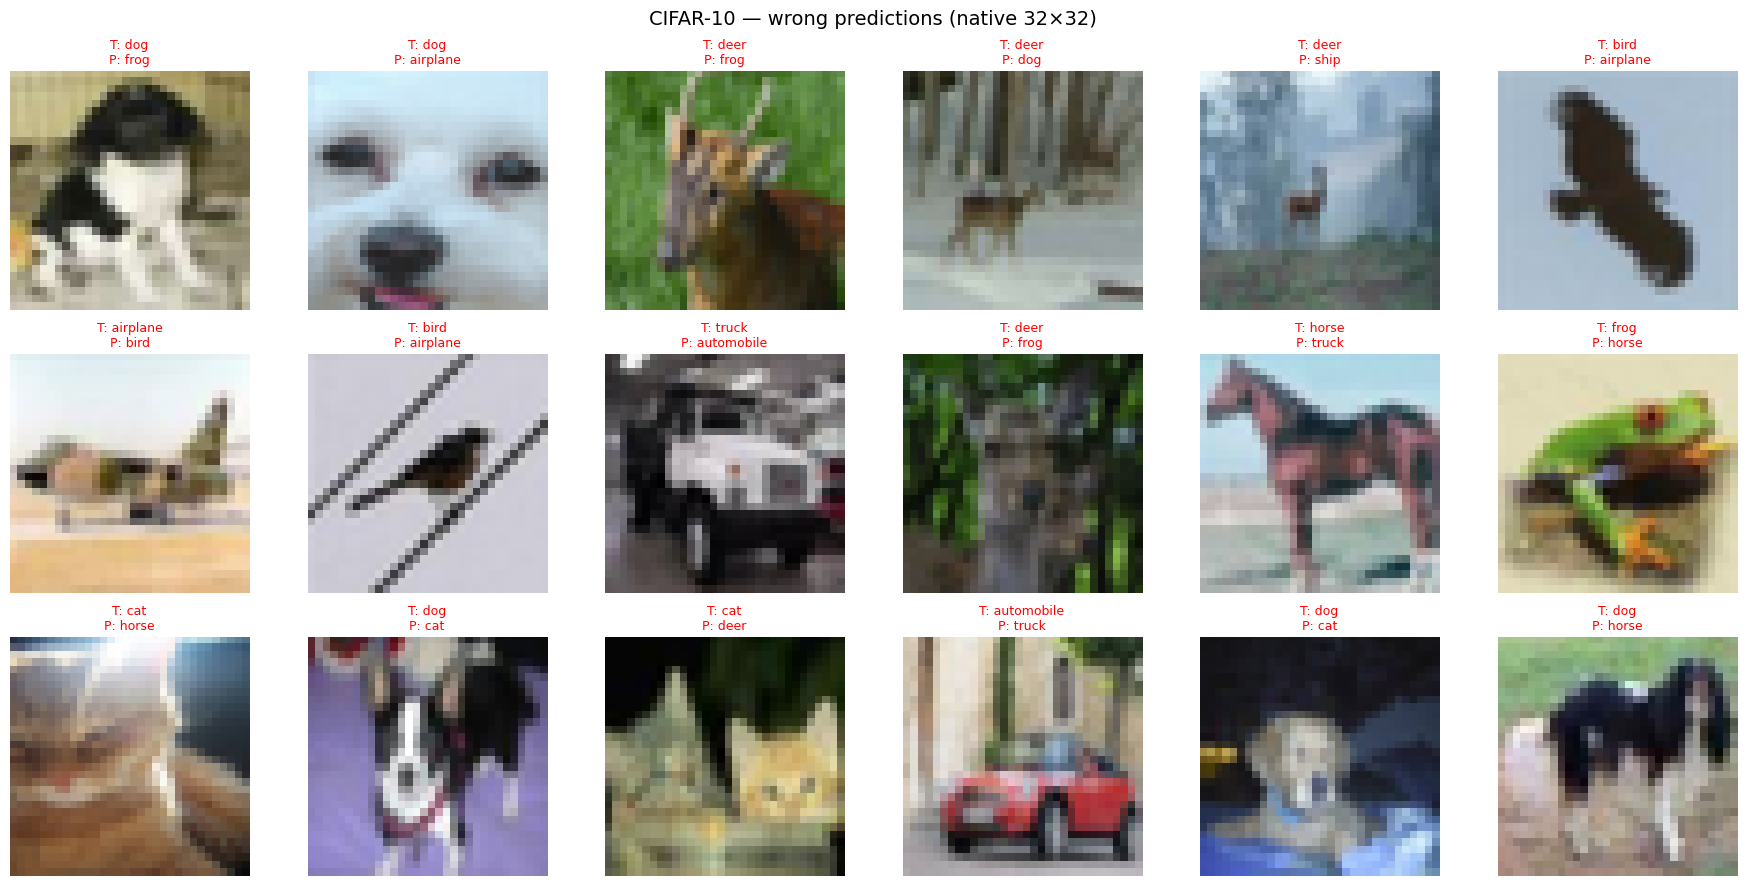

In [14]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=True, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — wrong predictions (native 32×32)")


In [15]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 333
truck -> automobile : 253
airplane -> ship : 231
horse -> dog : 229
deer -> frog : 179
automobile -> truck : 159
dog -> cat : 150
deer -> bird : 136
bird -> dog : 125
bird -> airplane : 123


#### 2.1.1bis - CNN - CIFAR-10 (Test CNN "V2")

- CNN_v2 has more conv blocks and uses BatchNorm

epochs: 100%|██████████| 5/5 [10:18<00:00, 123.62s/it, sec=112, tr_acc=0.556, tr_loss=1.248, va_acc=0.531, va_loss=1.334]



Saved best checkpoint to: weights/project_3/cnn_v2_cifar_test_5ep/cnn_v2_cifar_test_5ep_model_weights.pth
Metrics: {'best_val_acc': 0.5702875399361023, 'best_epoch': 4, 'final_val_acc': 0.5702875399361023, 'final_val_macro_f1': 0.5723452879984439, 'final_test_acc': 0.5621006389776357, 'final_test_macro_f1': 0.5644960052927753, 'total_training_time_sec': 618.0707819999952, 'train_peak_mem_bytes': 79250432, 'val_peak_mem_bytes': 79250432, 'test_peak_mem_bytes': 79250432, 'device': 'mps', 'lr': 0.0003, 'epochs': 5}
Saved to: weights/project_3/cnn_v2_cifar_test_5ep/cnn_v2_cifar_test_5ep_model_weights.pth
Final metrics: {'best_val_acc': 0.5702875399361023, 'best_epoch': 4, 'final_val_acc': 0.5702875399361023, 'final_val_macro_f1': 0.5723452879984439, 'final_test_acc': 0.5621006389776357, 'final_test_macro_f1': 0.5644960052927753, 'total_training_time_sec': 618.0707819999952, 'train_peak_mem_bytes': 79250432, 'val_peak_mem_bytes': 79250432, 'test_peak_mem_bytes': 79250432, 'device': 'mps', 

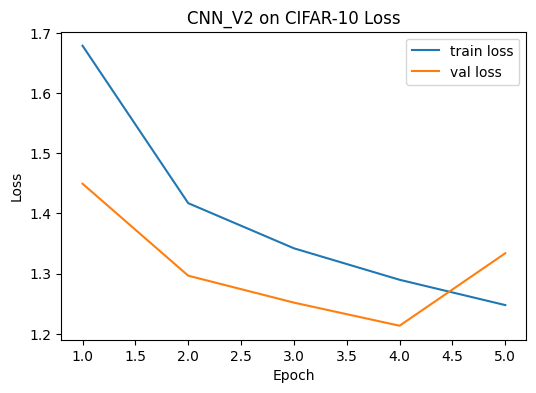

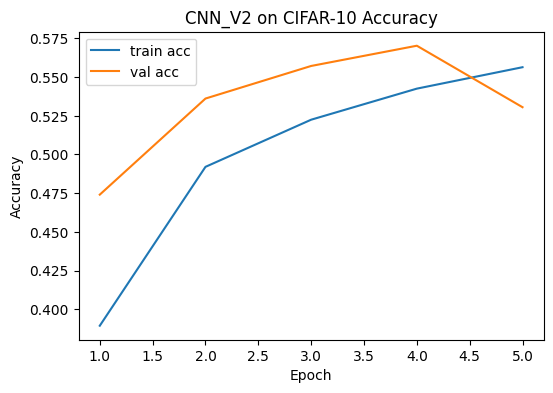

In [16]:
MODEL_NAME = "cnn_v2_cifar_test"
if TRAIN_CNN_V2_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN_v2(num_classes=cifar_num_classes).to(device)

    model_cnn_cifar, history, metrics, saved_path = train_model(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=5,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN_V2 on CIFAR-10")
    
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN_v2(num_classes=cifar_num_classes).to(device)
    model_cnn_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])



Test loss: 1.223236335542636
Test acc : 0.5621006389776357
Confusion matrix shape: (10, 10)


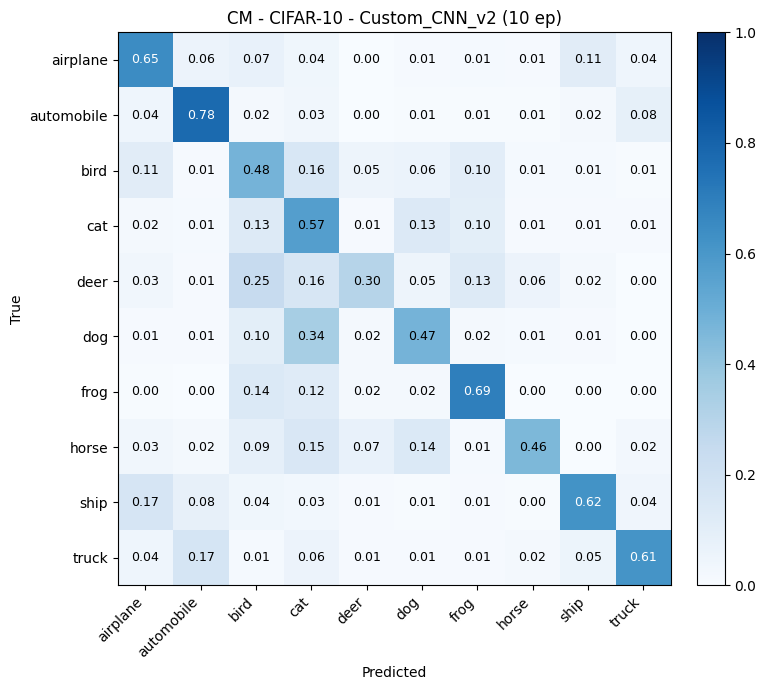

In [17]:
# Evaluate

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - Custom_CNN_v2 (10 ep)")

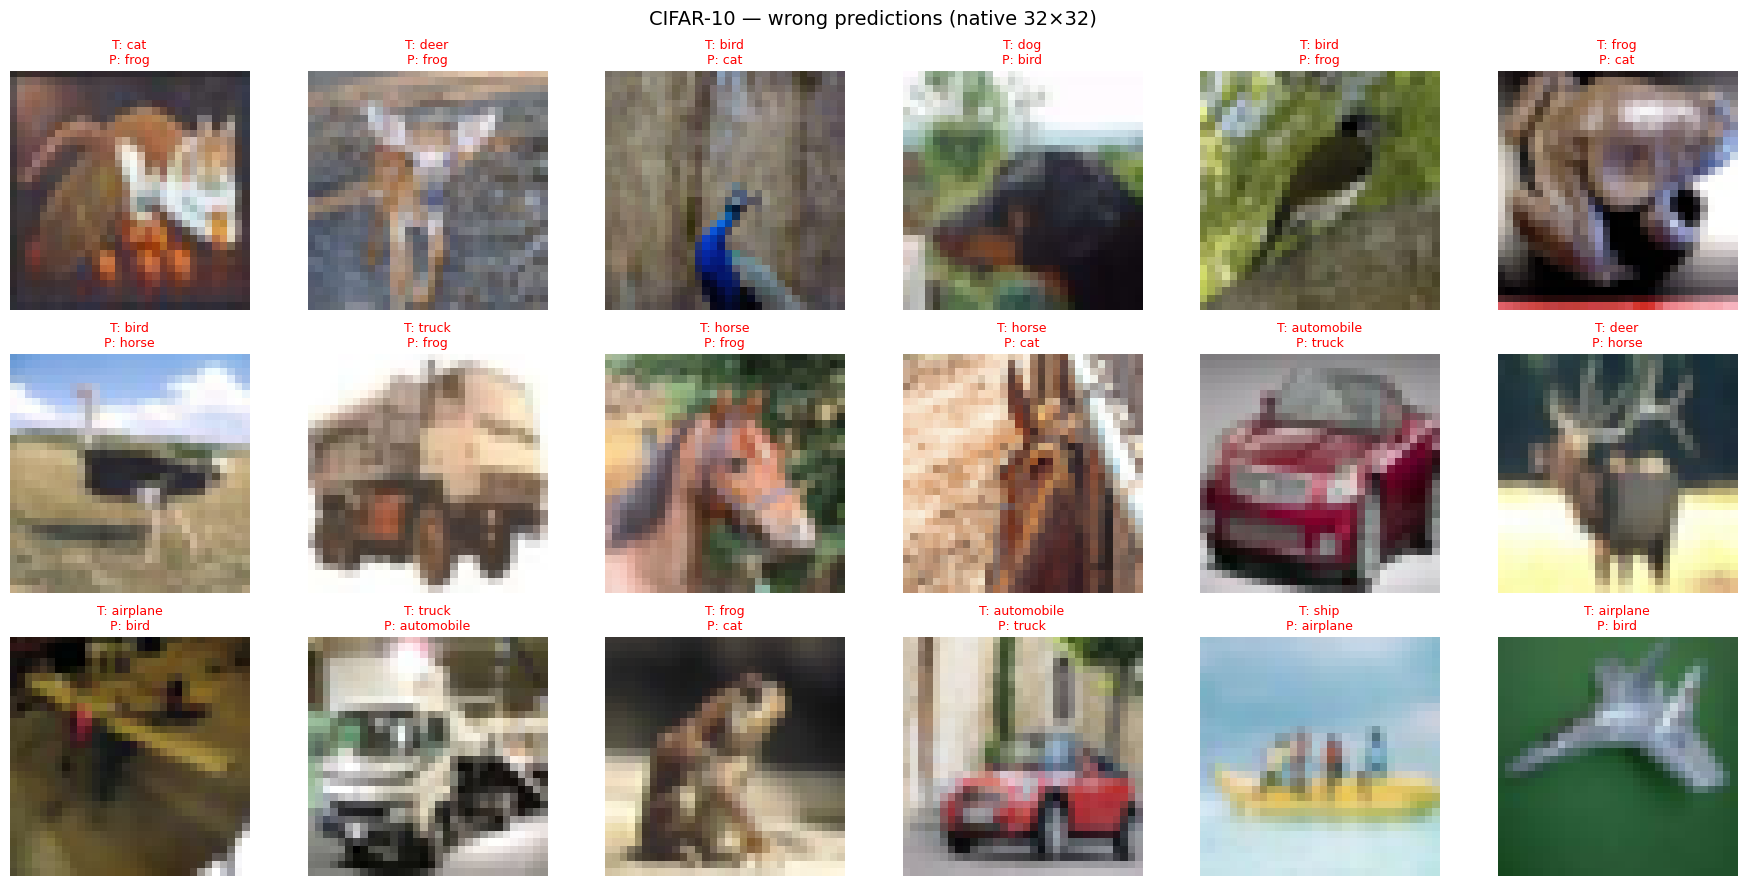

In [18]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=True, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — wrong predictions (native 32×32)")


In [19]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
dog -> cat : 345
deer -> bird : 246
truck -> automobile : 170
ship -> airplane : 166
deer -> cat : 159
bird -> cat : 156
horse -> cat : 150
horse -> dog : 140
frog -> bird : 138
cat -> dog : 133


#### 2.1.2 - CNN - FOOD-101

### 2.2 - ResNet-18

## 3 - Vision Transformers

### 3.1 - VisionTransformer-Tiny (ViT-Tiny)

### 3.2 - Swin Transformer-Tiny (Swin-Tiny)